# Collinear predictors

This notebook explores how we can use Gaussian graphical models to model the collinearity between predictors in linear regression.

In [13]:
%load_ext autoreload
%autoreload 2

import os

# For JAX, we can use CPU (set SELECTED_DEVICE to empty (''), or one of the available GPUs)
SELECTED_DEVICE = ''
print(f'Setting CUDA visible devices to [{SELECTED_DEVICE}]')
os.environ['CUDA_VISIBLE_DEVICES'] = f'{SELECTED_DEVICE}'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setting CUDA visible devices to []


In [14]:
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.random as jrnd
import jax.numpy as jnp
import numpyro.distributions as dist
import blackjax

import sys
import time

from bamojax.base import Model
from bamojax.samplers import mcmc_sampler, gibbs_sampler
from bamojax.inference import MCMCInference
from bamojax.more_distributions import GWishart, GraphBernoulli
from bamojax.gwishart import gwishart_drj, fixed_by_drj

from bamojax.marginal_likelihoods.bridge_sampling import bridge_sampling
from itertools import chain, combinations
from jax.scipy.special import logsumexp
import numpyro.distributions.transforms as nprb


print('Python version:     ', sys.version)
print('Jax version:        ', jax.__version__)
print('BlackJax version:   ', blackjax.__version__)
print('Jax default backend:', jax.default_backend())
print('Jax devices:        ', jax.devices())

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def pretty_axis(ax, fix_xaxis=True, fix_yaxis=True):
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False) 
    if fix_xaxis:
        ax.spines['bottom'].set_position(('axes', -0.05))
    if fix_yaxis:
        ax.spines['left'].set_position(('axes', -0.05))

#

Python version:      3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Jax version:         0.9.2
BlackJax version:    1.2.5
Jax default backend: cpu
Jax devices:         [CpuDevice(id=0)]


Generate some data in which one predictor is irrelevant and two predictors are collinear:

In [15]:
key = jrnd.PRNGKey(0)

key, key_x, key_y = jrnd.split(key, 3)

n = 100
rho = 0.9
s = 0.1

key_x1, key_x2, key_x3, key_x4 = jrnd.split(key_x, 4)

x0 = jnp.ones((n, ))
x1 = jrnd.normal(key_x1, shape=(n, ))
x2 = rho*x1 + (1-rho) * jrnd.normal(key_x2, shape=(n, ))
x3 = jrnd.normal(key_x3, shape=(n, ))
x4 = jrnd.normal(key_x4, shape=(n, ))
x = jnp.vstack([x0, x1, x2, x3, x4]).T

b = jnp.array([3, 0.5, 0.4, 0.0, 0.7])  # third predictor is not relevant

mu = x @ b

y = mu + s*jrnd.normal(key_y, shape=(n, ))

Enumerate and construct all models with different configurations of included predictors. Construct the models, train them, and estimate their marginal likelihoods via bridge sampling.

Note that we can use a conjugate prior to get these exactly, but here we use the general approach of MCMC sampling.

In [16]:
def powerset(iterable):
    """
    powerset([1,2,3]) --> () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)
    """
    xs = list(iterable)
    # note we return an iterator rather than a list
    return chain.from_iterable(combinations(xs,n) for n in range(len(xs)+1))

#
def create_regression_model(predictor_set, x, y):
    def linreg_fn(x_, b_, scale_):
        mu = x_ @ b_
        return dict(loc=mu, scale=scale_)
    
    #

    column_indices = jnp.array([0] + [index + 1 for index in predictor_set])
    x_model = x[:, column_indices]
    p = x_model.shape[1]

    model = Model(f'{predictor_set}')
    scale_node = model.add_node('sigma', distribution=dist.HalfNormal(1))
    beta_node = model.add_node('beta', distribution=dist.Normal(loc=0.0, scale=1.0), shape=(p, ))
    input_node = model.add_node('x', observations=x_model)
    output_node = model.add_node('y', distribution=dist.Normal, 
                                 parents=dict(x_=input_node, 
                                              b_=beta_node, 
                                              scale_=scale_node), 
                                 link_fn=linreg_fn, observations=y)
    return model

#
def get_posterior_samples(key, model, num_samples, num_warmup=1000):
    m = model.get_model_size()
    cold_nuts_parameters = dict(step_size=0.5, inverse_mass_matrix=0.0001*jnp.eye(m))  # these will be overriden by the window adaptation
    nuts_kernel = mcmc_sampler(model=model, mcmc_kernel=blackjax.nuts, mcmc_parameters=cold_nuts_parameters)
    engine = MCMCInference(model=model, mcmc_kernel=nuts_kernel, num_samples=num_samples, num_burn=0, num_warmup=num_warmup, num_thin=1)
    results = engine.run(key)
    return results['states']

#          
def get_marginal_likelihood(key, model, samples):
    lml, _ = bridge_sampling(key=key, model=model, posterior_samples=samples, bijectors=dict(beta=nprb.IdentityTransform()))
    return lml

#
p = x.shape[1] - 1
model_structures = list(powerset(set(range(p))))
num_samples = 10_000

models = []
posterior_samples = []
lmls = []

for pred_set in model_structures:
    tic = time.time()
    key, key_inf, key_lml = jrnd.split(key, 3)
    model = create_regression_model(pred_set, x, y)
    samples = get_posterior_samples(key_inf, model, num_samples)
    lml = get_marginal_likelihood(key_lml, model, samples)

    models.append(model)
    posterior_samples.append(samples)
    lmls.append(lml)
    toc = time.time()
    elapsed = toc - tic
    print(f'Model {model.name} sampled and evaluated in {elapsed:0.2f} seconds')


def lml2pmp(lml):
    lml = jnp.asarray(lml)
    return jnp.exp(lml - logsumexp(lml))

#

pmps = lml2pmp(lmls)
print(pmps)
    


Adapting NUTS HMC parameters... done.
Model () sampled and evaluated in 2.98 seconds
Adapting NUTS HMC parameters... done.
Model (0,) sampled and evaluated in 3.48 seconds
Adapting NUTS HMC parameters... done.
Model (1,) sampled and evaluated in 3.55 seconds
Adapting NUTS HMC parameters... done.
Model (2,) sampled and evaluated in 3.48 seconds
Adapting NUTS HMC parameters... done.
Model (3,) sampled and evaluated in 3.33 seconds
Adapting NUTS HMC parameters... done.
Model (0, 1) sampled and evaluated in 5.05 seconds
Adapting NUTS HMC parameters... done.
Model (0, 2) sampled and evaluated in 3.28 seconds
Adapting NUTS HMC parameters... done.
Model (0, 3) sampled and evaluated in 4.05 seconds
Adapting NUTS HMC parameters... done.
Model (1, 2) sampled and evaluated in 3.71 seconds
Adapting NUTS HMC parameters... done.
Model (1, 3) sampled and evaluated in 3.51 seconds
Adapting NUTS HMC parameters... done.
Model (2, 3) sampled and evaluated in 3.73 seconds
Adapting NUTS HMC parameters... d

Regular model comparison finds the correct model to be the best (note that the predictors in the name do not include the intercept):

In [17]:
pmps = lml2pmp(lmls)
print(pmps)

max_ix = jnp.argmax(jnp.asarray(lmls))
print('Best model includes these predictors:', models[max_ix].name)

[4.88896683e-96 1.75649743e-76 9.81639152e-77 6.38141329e-97
 3.25891904e-81 1.19049693e-76 1.07903215e-77 9.92420852e-02
 6.49019841e-78 2.50962503e-06 4.01157023e-82 7.51670362e-78
 8.90493901e-01 1.00085417e-03 5.65001735e-08 9.26059356e-03]
Best model includes these predictors: (0, 1, 3)


In [18]:
for m, model in enumerate(models):
    print(posterior_samples[m]['beta'].mean(axis=0))

[3.04976461]
[3.00643781 0.98137298]
[3.00781002 1.08028262]
[3.04163251 0.0746191 ]
[3.0405973 0.8235151]
[3.00718174 0.64780799 0.37443265]
[ 3.0076117   0.98266197 -0.0073327 ]
[3.00715217 0.86317022 0.70317965]
[ 3.00849869  1.08226381 -0.02412156]
[3.0071343  0.951087   0.70488627]
[3.03766884 0.07475942 0.82565052]
[ 3.00791949  0.6257561   0.40160041 -0.01524497]
[3.00677654 0.57214765 0.32420527 0.70283518]
[3.00699007e+00 8.63179541e-01 1.70106787e-03 7.03068823e-01]
[ 3.00747665  0.95350055 -0.01301579  0.70444007]
[ 3.00694901  0.56751532  0.3300494  -0.0033889   0.70285351]


Inclusion probabilities:

In [19]:
p = x.shape[1] - 1 # exclude intercept
M = len(model_structures)

print('Predictor            P(incl)    P(incl|data)    log BF_incl')

for i in range(p):
    prior_inclusion = jnp.sum(jnp.asarray([i in m for m in model_structures])) / M
    posterior_inclusion = jnp.sum(jnp.asarray([pmps[j] for j, m in enumerate(model_structures) if i in m ]))
    log_incl_bf = jnp.log((posterior_inclusion * (1 - prior_inclusion)) / (prior_inclusion * (1 - posterior_inclusion)))
    print(f'{str(i):20s} {str(prior_inclusion):10.6} {str(posterior_inclusion):15.6} {str(log_incl_bf):10.6}')

Predictor            P(incl)    P(incl|data)    log BF_incl
0                    0.5        0.9999          12.873    
1                    0.5        0.8997          2.1945    
2                    0.5        0.0102          -4.569    
3                    0.5        1.0000          nan       


Bayesian model averaged estimates:

In [20]:
def largest_remainder(weights, total):
    """Allocate `total` items over bins so counts sum exactly to total."""
    weights = jnp.asarray(weights, dtype=float)
    raw = weights * total
    floor = jnp.floor(raw).astype(int)
    deficit = total - floor.sum()
    order = jnp.argsort(-(raw - floor))     
    floor = floor.at[order[:deficit]].add(1)
    return floor

def extract_beta(states):
    """Return beta draws as (N, p_model), flattening any chain dimension."""
    beta = jnp.asarray(states['beta'])
    return beta.reshape((-1, beta.shape[-1]))

# per-model sample budget (same for every predictor, depends only on the model)
counts = largest_remainder(jnp.asarray(pmps), num_samples)   # sums to num_samples

key, subkey = jrnd.split(key)
model_keys = jrnd.split(subkey, len(model_structures))

bma_beta = {i: [] for i in range(p)}
bma_intercept = []                                          # always included

for j, m in enumerate(model_structures):
    n_j = int(counts[j])
    if n_j == 0:
        continue
    beta_j = extract_beta(posterior_samples[j])
    N_j = beta_j.shape[0]
    rows = jrnd.choice(model_keys[j], N_j, shape=(n_j,), replace=(n_j > N_j))

    bma_intercept.append(beta_j[rows, 0])

    for i in range(p):
        if i in m:
            col = m.index(i) + 1                            # +1 skips the intercept
            bma_beta[i].append(beta_j[rows, col])
        else:
            bma_beta[i].append(jnp.zeros(n_j))              # spike at zero

bma_intercept = jnp.concatenate(bma_intercept)
for i in range(p):
    bma_beta[i] = jnp.concatenate(bma_beta[i]) 


print('Term          BMA mean      BMA sd     P(incl|data)      95% CI')
lo, hi = jnp.percentile(bma_intercept, jnp.array([2.5, 97.5]))
print(f'{"intercept":<10} {jnp.mean(bma_intercept):>10.4f} {jnp.std(bma_intercept):>10.4f} '
      f'{1.0:>12.4f}     [{lo:.4f}, {hi:.4f}]')

for i in range(p):
    s = bma_beta[i]
    incl = jnp.mean(s != 0.0)
    lo, hi = jnp.percentile(s, jnp.array([2.5, 97.5]))
    print(f'{i:<10} {jnp.mean(s):>10.4f} {jnp.std(s):>10.4f} '
          f'{incl:>12.4f}     [{lo:.4f}, {hi:.4f}]')

Term          BMA mean      BMA sd     P(incl|data)      95% CI
intercept      3.0068     0.0106       1.0000     [2.9860, 3.0275]
0              0.6018     0.1275       1.0000     [0.3815, 0.8722]
1              0.2912     0.1413       0.8998     [0.0000, 0.5326]
2             -0.0000     0.0010       0.0103     [0.0000, 0.0000]
3              0.7028     0.0115       1.0000     [0.6800, 0.7257]


Text(0.5, 0.98, 'BMA coefficient estimates')

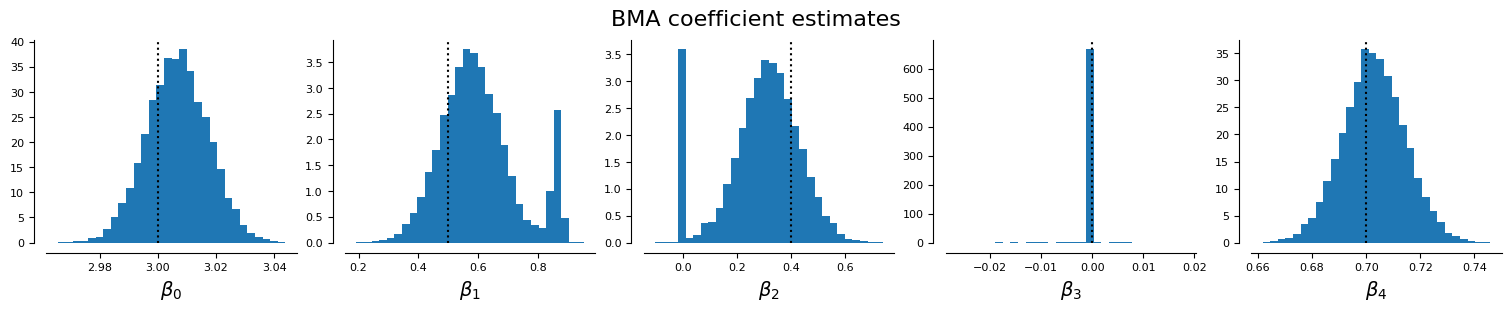

In [21]:
num_bins = 30

_, axes = plt.subplots(nrows=1, ncols=p+1, constrained_layout=True, figsize=(15, 3))
axes[0].hist(bma_intercept, bins=num_bins, density=True)
axes[0].set_xlabel(r'$\beta_0$')
axes[0].axvline(x=b[0], ls=':', c='k')

for j in range(p):    
    axes[j+1].hist(bma_beta[j], bins=num_bins, density=True)
    axes[j+1].axvline(x=b[j+1], ls=':', c='k')
    axes[j+1].set_xlabel(rf'$\beta_{j+1}$')

for ax in axes:
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    pretty_axis(ax)

plt.suptitle('BMA coefficient estimates')

# Conditional variable selection

Now try with the GGM approach. Here we model the joint $[X, y]$ with a $G$-Wishart prior:

$$
\begin{align*}
    G_{ij} & \sim \text{Bernoulli}(\theta=0.5) \\
    \mathbf{K} \mid G &\sim \text{$G$-Wishart}_p(\delta=3, \mathbf{D}=\mathbf{I}_p) \\
    Y_n \mid \mathbf{K} &\sim \text{MVNormal}(\mathbf{0}, \mathbf{K})
\end{align*}
$$

We estimate both the binary graph $G$ and precision matrix $K$, which we can scale to partial correlations.

In [22]:
def create_linreg_GGM_prior(Vc, delta, D):
    p = Vc.shape[1]
    mu = jnp.zeros((p, ))
    def ggm_link_fn(K):
        return dict(loc=mu, precision_matrix=K)

    #
    model = Model('Joint GGM regression')
    G_node = model.add_node('G', distribution=GraphBernoulli(p=p, edge_prob=0.5))
    K_node = model.add_node('K', distribution=GWishart, parents=dict(G=G_node, dof=delta, scale=D))
    obs_node = model.add_node('X', 
                              distribution=dist.MultivariateNormal,
                              parents=dict(K=K_node),
                              observations=Vc,
                              link_fn=ggm_link_fn)

    return model

#

X = x[:, 1:]  # We can't model an intercept in the GGM
V = jnp.concatenate([X, y[:, None]], axis=1)
Vc = V - jnp.mean(V, axis=0)
n, p = Vc.shape

U = Vc.T @ Vc
delta, D = p - 1, jnp.eye(p)

ggm_model = create_linreg_GGM_prior(Vc, delta, D)

step_fns = dict(G=gwishart_drj, 
                K=fixed_by_drj)
step_fn_params = dict(G=dict(name='G', k_name='K', dof=delta, scale=D, n=n, U=U,
                          sigma_g=1.0,
                          logprior_G_fn=GraphBernoulli(p=p, edge_prob=0.5).log_prob),
                  K=dict())
gibbs_kernel = gibbs_sampler(ggm_model, step_fns=step_fns, step_fn_params=step_fn_params)

num_samples, num_burn = 100_000, 50_000
engine = MCMCInference(model=ggm_model, num_chains=1, num_samples=num_samples,
                       num_burn=num_burn, num_thin=1, mcmc_kernel=gibbs_kernel,
                       return_diagnostics=True)

tic = time.time()
result = engine.run(jrnd.PRNGKey(1234))
toc = time.time()
elapsed = toc - tic
print(f'GGM model training done in {elapsed:0.2f}')

GGM model training done in 7.04


The GGM approach does not model the intercept, so we obtain that post-hoc, and we show the BMA coefficients:

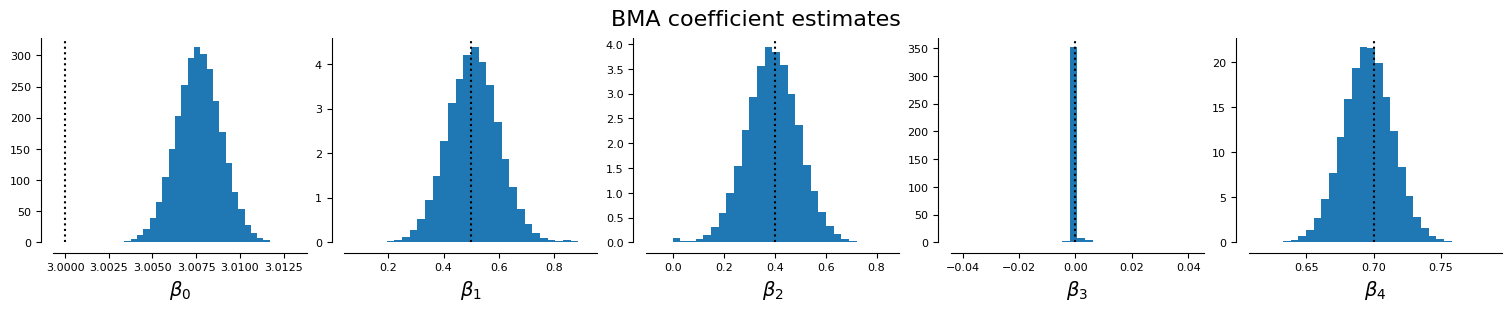

In [23]:
Ks     = result['states']['K']
slopes = -Ks[:, -1, :-1] / Ks[:, -1, -1:]
x_bar, y_bar   = X.mean(axis=0), y.mean()
intercept_post = y_bar - slopes @ x_bar
slope_mean     = slopes.mean(axis=0)
intercept_mean = intercept_post.mean()

num_bins = 30

_, axes = plt.subplots(nrows=1, ncols=p, constrained_layout=True, figsize=(15, 3))

axes[0].hist(intercept_post, bins=num_bins, density=True)
axes[0].axvline(x=b[0], ls=':', c='k')
axes[0].set_xlabel(r'$\beta_0$')
for j in range(p-1):    
    axes[j+1].hist(slopes[:, j], bins=num_bins, density=True)
    axes[j+1].axvline(x=b[j+1], ls=':', c='k')
    axes[j+1].set_xlabel(rf'$\beta_{j+1}$')

for ax in axes:
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    pretty_axis(ax)

plt.suptitle('BMA coefficient estimates');

The inclusion probabilities are now conditional rather than marginal; they show how likely one variable should be included conditioned on the others:

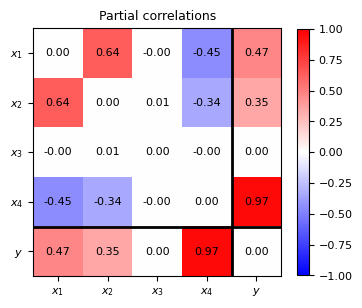

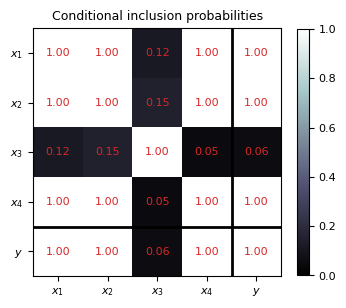

In [24]:
def precision2partial(K):
    """Convert precision matrix to partial correlation matrix."""
    D = jnp.diag(1.0 / jnp.sqrt(jnp.diag(K)))
    return -D @ K @ D + jnp.eye(K.shape[0])

#

Gs = result['states']['G']
Ks = result['states']['K']
Rs = jax.vmap(precision2partial)(Ks)


R_exp = Rs.mean(axis=0)
plt.figure(figsize=(4, 4))
fig = plt.gcf()
ax = plt.gca()
pos = ax.imshow(R_exp, vmin=-1.0, vmax=1.0, cmap=plt.get_cmap('bwr'))
cbar = fig.colorbar(pos, ax=ax, shrink=0.8)
cbar.ax.tick_params(labelsize=8)
ax.set_xticks(jnp.arange(p))
ax.set_xticklabels([fr'$x_{i+1}$' for i in range(p-1)] + [r'$y$'], fontsize=8)
ax.set_yticks(jnp.arange(p))
ax.set_yticklabels([fr'$x_{i+1}$' for i in range(p-1)] + [r'$y$'], fontsize=8);
ax.axvline(x=p-1.5, ls='-', lw=2, color='k')
ax.axhline(y=p-1.5, ls='-', lw=2, color='k')

for i in range(p):
    for j in range(p):
        ax.text(i, j, f'{R_exp[i, j]:0.2f}', ha='center', va='center', fontsize=8)

ax.set_title('Partial correlations', fontsize=9);

G_exp = Gs.mean(axis=0)
plt.figure(figsize=(4, 4))
fig = plt.gcf()
ax = plt.gca()
pos = ax.imshow(G_exp, vmin=0.0, vmax=1.0, cmap=plt.get_cmap('bone'))
cbar = fig.colorbar(pos, ax=ax, shrink=0.8)
cbar.ax.tick_params(labelsize=8)
ax.set_xticks(jnp.arange(p))
ax.set_xticklabels([fr'$x_{i+1}$' for i in range(p-1)] + [r'$y$'], fontsize=8)
ax.set_yticks(jnp.arange(p))
ax.set_yticklabels([fr'$x_{i+1}$' for i in range(p-1)] + [r'$y$'], fontsize=8);
ax.axvline(x=p-1.5, ls='-', lw=2, color='k')
ax.axhline(y=p-1.5, ls='-', lw=2, color='k')

for i in range(p):
    for j in range(p):
        ax.text(i, j, f'{G_exp[i, j]:0.2f}', ha='center', va='center', fontsize=8, color='tab:red')

ax.set_title('Conditional inclusion probabilities', fontsize=9);

The final column shows the partial correlations / inclusion probabilities for the predictors; $x_1$, $x_2$, and $x_4$ should be included, while $x_3$ is irrelevant. However, the inclusion probabilities for the first two predictors are perhaps surprisingly low. The explanation for this observation comes from their collinearity, which is captured in the partial correlation between $x_1$ and $x_2$.